Description: Discover patterns in data without labeled outcomes.

Algorithms:
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN
- Principal Component Analysis (PCA)
- t-SNE for visualization
- Association Rule Learning (Apriori)

Hands-on Projects:
- Customer Segmentation: Group customers based on purchasing behavior
- Anomaly Detection: Identify fraudulent transactions
- Image Compression: Use K-Means for color quantization

## 1. Customer Segmentation

In [2]:
import pandas as pd

df = pd.read_csv("../../datasets/customer_segmentation.csv")

X = df[["Age", "Work_Experience", "Family_Size"]]

In [3]:
X = X.fillna(X.median())

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4)

df["Cluster"] = kmeans.fit_predict(X)

print(df[["Age", "Work_Experience", "Family_Size", "Cluster"]].head())

   Age  Work_Experience  Family_Size  Cluster
0   22              1.0          4.0        3
1   38              NaN          3.0        0
2   67              1.0          1.0        1
3   67              0.0          2.0        1
4   40              NaN          6.0        0


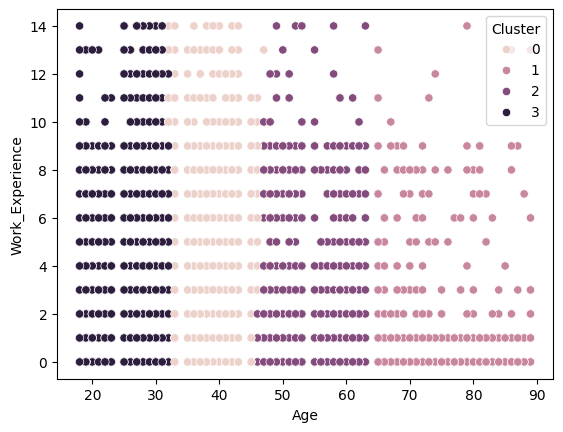

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x="Age",
    y="Work_Experience",
    hue="Cluster",
    data=df
)

plt.show()

print(pd.crosstab(
    df["Cluster"],
    df["Segmentation"]
))

## 2. Anomaly Detection

In [6]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../../datasets/blood_cell_anomaly_detection.csv")

X = df.drop(["cell_id", "anomaly_label"], axis=1)

X = pd.get_dummies(X)

In [8]:
model = IsolationForest(random_state=42)

y_pred = model.fit_predict(X)

# Isolation Forest returns:
#  1 = Normal
# -1 = Anomaly

y_pred = [0 if i == 1 else 1 for i in y_pred]

print(confusion_matrix(df["anomaly_label"], y_pred))
print(classification_report(df["anomaly_label"], y_pred))

df["Predicted"] = y_pred

print(df[["anomaly_label", "Predicted"]].head())

[[3956   44]
 [1070  810]]
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      4000
           1       0.95      0.43      0.59      1880

    accuracy                           0.81      5880
   macro avg       0.87      0.71      0.73      5880
weighted avg       0.84      0.81      0.79      5880

   anomaly_label  Predicted
0              1          1
1              1          0
2              0          0
3              0          0
4              0          0


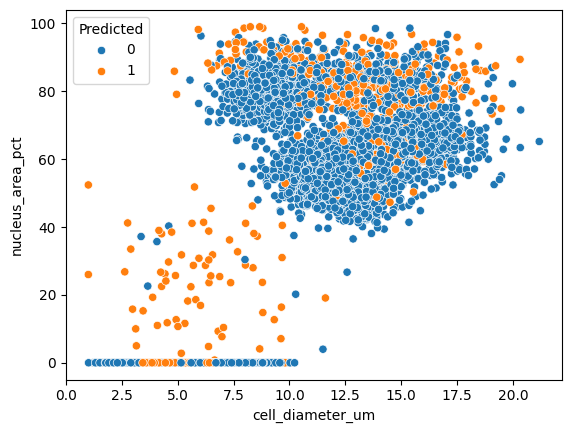

In [9]:
sns.scatterplot(
    x="cell_diameter_um",
    y="nucleus_area_pct",
    hue="Predicted",
    data=df
)

plt.show()

## 3. Image Compression

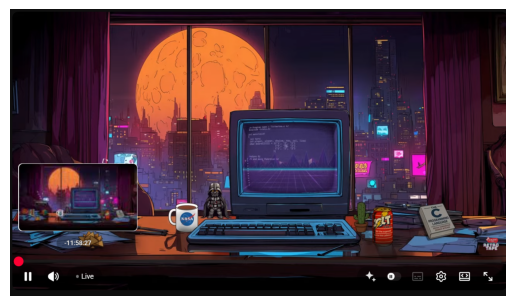

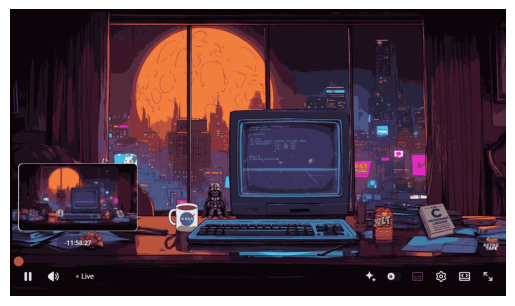

In [18]:
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

img = Image.open("../../images/image.png").convert("RGB")

img_array = np.array(img)


pixels = img_array.reshape(-1, 3)

kmeans = KMeans(n_clusters=16, random_state=42)

kmeans.fit(pixels)

compressed = kmeans.cluster_centers_[kmeans.labels_]

compressed = compressed.reshape(img_array.shape)

compressed = compressed.astype(np.uint8)

plt.imshow(img)
plt.axis("off")
plt.show()

plt.imshow(compressed)
plt.axis("off")
plt.show()

In [16]:
compressed_img = Image.fromarray(compressed)

compressed_img.save("../../images/compressed image.png")

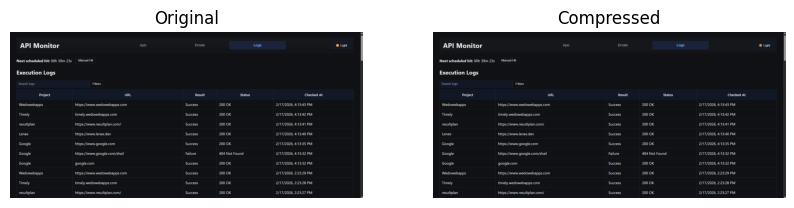